# Hangman Environment — Visual Demo
Runs each agent through a game and draws the board state at every step.

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
from IPython.display import clear_output
import time

from environment import HangmanEnvironment
from benchmark import load_word_list
from agents import get_all_agents, RandomAgent, EntropyAgent, FrequencyAgent

In [2]:
# ── Drawing helpers ────────────────────────────────────────────────────────

def draw_gallows(ax, wrong: int, max_wrong: int = 8):
    """Draw the hangman figure using matplotlib lines/circles."""
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 12)
    ax.set_aspect('equal')
    ax.axis('off')

    # ── Gallows structure ──
    lw = 3
    color = '#333333'
    # base
    ax.plot([1, 9], [1, 1], color=color, lw=lw)
    # pole
    ax.plot([3, 3], [1, 11], color=color, lw=lw)
    # top beam
    ax.plot([3, 7], [11, 11], color=color, lw=lw)
    # rope
    ax.plot([7, 7], [11, 9.5], color=color, lw=lw)
    # diagonal brace
    ax.plot([3, 5], [9, 11], color='#888888', lw=1.5)

    body_color = '#C0392B' if wrong >= max_wrong else '#2C3E50'

    # head
    if wrong >= 1:
        head = plt.Circle((7, 8.8), 0.7, color=body_color, fill=False, lw=2)
        ax.add_patch(head)
    # body
    if wrong >= 2:
        ax.plot([7, 7], [8.1, 5.5], color=body_color, lw=2)
    # left arm
    if wrong >= 3:
        ax.plot([7, 5.2], [7.5, 6.2], color=body_color, lw=2)
    # right arm
    if wrong >= 4:
        ax.plot([7, 8.8], [7.5, 6.2], color=body_color, lw=2)
    # left leg
    if wrong >= 5:
        ax.plot([7, 5.5], [5.5, 4.0], color=body_color, lw=2)
    # right leg
    if wrong >= 6:
        ax.plot([7, 8.5], [5.5, 4.0], color=body_color, lw=2)
    # left foot
    if wrong >= 7:
        ax.plot([5.5, 4.5], [4.0, 4.0], color=body_color, lw=2)
    # right foot
    if wrong >= 8:
        ax.plot([8.5, 9.5], [4.0, 4.0], color=body_color, lw=2)


def draw_word(ax, masked_word: str, won: bool):
    """Draw the masked/revealed word as letter tiles."""
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    n = len(masked_word)
    tile_w = min(0.9 / n, 0.12)
    gap = tile_w * 0.2
    total = n * tile_w + (n - 1) * gap
    x0 = (1 - total) / 2

    for i, ch in enumerate(masked_word):
        x = x0 + i * (tile_w + gap)
        revealed = ch != '_'
        bg = '#27AE60' if (revealed and won) else ('#3498DB' if revealed else '#ECF0F1')
        rect = mpatches.FancyBboxPatch(
            (x, 0.25), tile_w, 0.5,
            boxstyle='round,pad=0.01',
            facecolor=bg, edgecolor='#BDC3C7', lw=1
        )
        ax.add_patch(rect)
        if revealed:
            ax.text(x + tile_w / 2, 0.5, ch.upper(),
                    ha='center', va='center', fontsize=14,
                    fontweight='bold', color='white')


def draw_letters(ax, guessed: set, secret_word: str, remaining: list):
    """Draw the 26-letter alphabet coloured by guess outcome."""
    ax.set_xlim(0, 26)
    ax.set_ylim(0, 2)
    ax.axis('off')

    alphabet = 'abcdefghijklmnopqrstuvwxyz'
    for i, ch in enumerate(alphabet):
        if ch in guessed:
            color = '#27AE60' if ch in secret_word else '#E74C3C'
            txt_color = 'white'
        else:
            color = '#ECF0F1'
            txt_color = '#95A5A6'
        rect = mpatches.FancyBboxPatch(
            (i + 0.1, 0.2), 0.8, 1.1,
            boxstyle='round,pad=0.05',
            facecolor=color, edgecolor='#BDC3C7', lw=0.5
        )
        ax.add_patch(rect)
        ax.text(i + 0.5, 0.75, ch.upper(),
                ha='center', va='center', fontsize=8,
                fontweight='bold', color=txt_color)


def render_state(obs, game, agent_name, step, reward, total_reward, event, delay=0.6):
    """Full-page render of the current game state."""
    fig = plt.figure(figsize=(12, 6), facecolor='#FAFAFA')
    gs = gridspec.GridSpec(3, 2, figure=fig,
                           height_ratios=[0.6, 3, 1],
                           hspace=0.35, wspace=0.3)

    wrong = obs['wrong_guesses']
    max_wrong = obs['max_wrong_guesses']
    masked = obs['masked_word']
    guessed = set(obs['guessed_letters'])
    secret = game.secret_word

    # ── Title ──
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis('off')
    status = ''
    if obs['is_won']:
        status = f'  ✓ WIN!'
        title_color = '#27AE60'
    elif obs['is_lost']:
        status = f'  ✗ LOST  (word: {secret})'
        title_color = '#E74C3C'
    else:
        title_color = '#2C3E50'
    ax_title.text(0.5, 0.5,
                  f'{agent_name}   |   Step {step}   |   Event: {event}'  
                  f'   |   Reward: {reward:+.1f}   |   Total: {total_reward:+.1f}{status}',
                  ha='center', va='center', fontsize=11,
                  color=title_color, fontweight='bold')

    # ── Gallows ──
    ax_gallows = fig.add_subplot(gs[1, 0])
    draw_gallows(ax_gallows, wrong, max_wrong)
    ax_gallows.set_title(
        f'Wrong guesses: {wrong} / {max_wrong}',
        fontsize=10, color='#7F8C8D'
    )

    # ── Word ──
    ax_word = fig.add_subplot(gs[1, 1])
    draw_word(ax_word, masked, obs['is_won'])
    ax_word.set_title(
        f'{masked.count("_")} letters remaining',
        fontsize=10, color='#7F8C8D'
    )

    # ── Letter grid ──
    ax_letters = fig.add_subplot(gs[2, :])
    draw_letters(ax_letters, guessed, secret, obs['remaining_letters'])

    plt.tight_layout()
    plt.show()
    if delay:
        time.sleep(delay)

## Single game — watch an agent play step by step

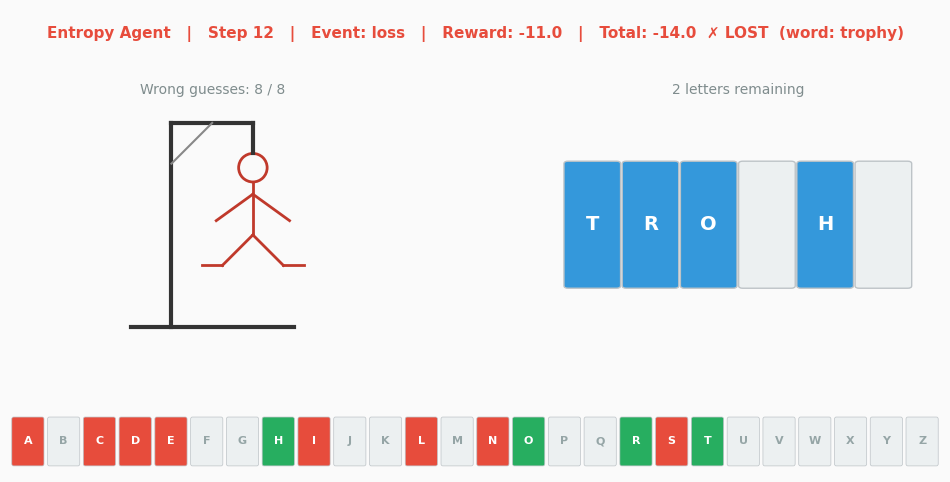

Done in 12 guesses — LOST


In [3]:
word_list = load_word_list()
env = HangmanEnvironment(word_list=word_list, seed=42)
agent = EntropyAgent()

obs = env.reset(word="trophy")   # ← change the word here, or use env.reset() for random

step = 0
total_reward = 0.0

while not env.is_done:
    letter = agent.pick_letter(obs, word_list)
    result = env.step(letter)
    step += 1
    total_reward += result.reward

    clear_output(wait=True)
    render_state(
        obs=result.observation,
        game=env.game,
        agent_name=agent.name,
        step=step,
        reward=result.reward,
        total_reward=total_reward,
        event=result.info['event'],
        delay=0.0,   # set to e.g. 0.8 for animation
    )
    obs = result.observation

print(f"Done in {step} guesses — {'WON' if env.game.is_won else 'LOST'}")

## Compare all agents — bar charts

In [ ]:
import random as _random

N_GAMES = 100
SEED    = 7

_random.seed(SEED)
test_words = _random.sample(word_list, min(N_GAMES, len(word_list)))
agents = get_all_agents()

results = {}   # agent_name -> {win_rate, avg_wrong, avg_reward}

for agent in agents:
    win_count   = 0
    total_wrong = 0
    total_rew   = 0.0

    for word in test_words:
        env2 = HangmanEnvironment(word_list=word_list)
        obs2 = env2.reset(word=word)
        ep_rew = 0.0
        while not env2.is_done:
            letter = agent.pick_letter(obs2, word_list)
            r = env2.step(letter)
            ep_rew += r.reward
            obs2 = r.observation
        win_count   += int(env2.game.is_won)
        total_wrong += env2.game.wrong_guesses
        total_rew   += ep_rew

    results[agent.name] = {
        'win_rate':  win_count / N_GAMES * 100,
        'avg_wrong': total_wrong / N_GAMES,
        'avg_reward': total_rew / N_GAMES,
    }

# ── Plot ──────────────────────────────────────────────────────────────────
names = [a.name for a in agents]
colors = ['#E74C3C', '#3498DB', '#9B59B6', '#F39C12', '#27AE60']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='#FAFAFA')
fig.suptitle(f'Agent Comparison — {N_GAMES} games each', fontsize=14, fontweight='bold')

metrics = [
    ('win_rate',   'Win Rate (%)',      True),
    ('avg_wrong',  'Avg Wrong Guesses', False),
    ('avg_reward', 'Avg Total Reward',  True),
]

for ax, (key, label, higher_better) in zip(axes, metrics):
    vals = [results[n][key] for n in names]
    best_idx = (vals.index(max(vals)) if higher_better else vals.index(min(vals)))
    bar_colors = ['#BDC3C7'] * len(names)
    bar_colors[best_idx] = colors[best_idx]

    bars = ax.bar(range(len(names)), vals, color=bar_colors, edgecolor='white', width=0.6)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.replace(' Agent', '') for n in names],
                       rotation=20, ha='right', fontsize=9)
    ax.set_ylabel(label, fontsize=10)
    ax.set_facecolor('#FAFAFA')
    ax.spines[['top', 'right']].set_visible(False)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()